# Create finetuned models

#### We finetune models, to enhance their ability to create meaningful distinctions in our dataset. To motivate this, let us begin with looking at a 2D representation of where jina-embeddings-v2-small-en places the survey responses in the embedding space.

First, we import.

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
from itertools import product
import os
from sentence_transformers import SentenceTransformer
import torch
import torch
from enum import Enum
from datasets import load_dataset
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments
)
from sentence_transformers.losses import ContrastiveLoss
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from sklearn.manifold import TSNE

/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initialize the embedding model, load the data and embed it.

In [2]:
# initialize model and prompt
# Note: The model_name and prompt can be changed as needed.
model_name = 'jinaai/jina-embeddings-v2-base-en'
prompt = ''

model = SentenceTransformer(
    model_name,
    trust_remote_code=True
)

In [3]:
# load the dataset
dataset = pd.read_excel('sources_amended.xlsx')
dataset.head()

,Response,code
0,Imprecise/faulty measuring tools,L
1,air fluctuations,L
2,Slight differences in experimental setup: tabl...,L
3,The material of ramp and ball and the coeffici...,L
4,Materials issues (ball; ramps are identical),L


In [4]:
# embed the dataset
embeddings = model.encode(
    dataset['Response'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

# add embeddings to the dataset
dataset['embedding'] = embeddings.tolist()

dataset.head()

Batches: 100%|██████████| 91/91 [00:06<00:00, 14.15it/s]


,Response,code,embedding
0,Imprecise/faulty measuring tools,L,"[-0.010014945641160011, -0.031923674046993256,..."
1,air fluctuations,L,"[-0.03653107210993767, -0.04496714472770691, 0..."
2,Slight differences in experimental setup: tabl...,L,"[-0.04071728140115738, -0.033269673585891724, ..."
3,The material of ramp and ball and the coeffici...,L,"[-0.024769000709056854, -0.057986337691545486,..."
4,Materials issues (ball; ramps are identical),L,"[0.02394707500934601, -0.04275062307715416, 0...."


Visualize using t-SNE.

In [5]:
rcParams.update({
    "figure.dpi": 600,
    "savefig.dpi": 600,
    "font.size": 8,              
    "axes.labelsize": 6,
    "axes.titlesize": 8,
    "legend.fontsize": 6,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "grid.linewidth": 0.5,
    "lines.markersize": 3.0,
})

_MARKERS = [
    "o", "s", "D", "X", "^", "v", ">", "<", "P", "*", "+", "x"
]


def _style_lookup(codes, palette=None, markers=None):
    """Map each unique code to a colour and a marker symbol."""
    unique = list(dict.fromkeys(codes))  # preserve original order

    # --- colours ---
    if palette is None:
        palette = sns.color_palette("tab10", len(unique))
    elif isinstance(palette, dict):
        palette = [palette.get(c, "#cccccc") for c in unique]
    colours = dict(zip(unique, palette))

    # --- markers ---
    if isinstance(markers, dict):
        marker_map = {c: markers.get(c, "o") for c in unique}
    else:
        marker_cycle = markers if markers is not None else _MARKERS
        marker_map = {
            c: marker_cycle[i % len(marker_cycle)] for i, c in enumerate(unique)
        }
    return colours, marker_map


def _scatter_plot(
    xy,
    codes,
    *,
    width_cm=8.6,
    palette=None,
    markers=None,
    x_label="Component 1",
    y_label="Component 2",
    title=None,
    save_as=None,
    show_grid=True,
):
    """Internal plotting engine; returns (fig, ax)."""
    colours, marker_map = _style_lookup(codes, palette, markers)

    # Seaborn styling
    style = "whitegrid" if show_grid else "white"
    sns.set_theme()

    # Figure size
    width_in = width_cm / 2
    height_in = width_in  # square by default – override as needed

    fig, ax = plt.subplots(figsize=(width_in, width_in))

    for code in np.unique(codes):
        mask = np.asarray(codes) == code
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            c=[colours[code]],
            marker=marker_map[code],
            s=18,  # ≈ 3 pt at 600 dpi
            edgecolors="none",
            label=code,
        )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    ax.set_xticks([])     
    ax.set_yticks([])    

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

    if title:
        ax.set_title(title, pad=4)
        
    ax.set_aspect("equal", adjustable="box")

    # Clean up spines but keep axes visible
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5)

    ax.legend(
        title="Code",
        frameon=False,
        handletextpad=0.3,
        labelspacing=0.4,
        borderpad=0.2,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0.0,
    )

    plt.tight_layout(pad=0.2)

    if save_as:
        fig.savefig(save_as, bbox_inches="tight")
        
    return fig, ax


def plot_tsne_embeddings(
    embedding_matrix,
    codes,
    *,
    random_state=0,
    perplexity=30,
    width_cm=8.6,
    palette=None,
    markers=None,
    save_as=None,
):
    """
    Parameters
    ----------
    embedding_matrix : (n_samples, n_features) array‑like
    codes            : iterable of length n_samples
    random_state     : int, default 0
    perplexity       : float, default 30
    width_cm         : figure width in centimetres (8.6 cm = single column)
    palette, markers : dict / list / None (see _style_lookup)
    save_as          : str or path; if given, saves figure
    """
    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        perplexity=perplexity,
        init="pca",
        metric="cosine",
    )
    xy = tsne.fit_transform(embedding_matrix)

    return _scatter_plot(
        xy,
        codes,
        width_cm=width_cm,
        palette=palette,
        markers=markers,
        x_label="t‑SNE 1",
        y_label="t‑SNE 2",
        title=None,
        save_as=save_as,
        show_grid=True,
    )

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/var/folders/ws/j2ktg5hj42s9mkbwr_c5lbtm0000gs/T/ipykernel_3672/1641009476.py:111: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(pad=0.2)
/var/folders/ws/j2ktg5hj42s9mkbwr_c5lbtm0000gs/T/ipykernel_3672/1641009476.py:114: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.savefig(save_as, bbox_inches="tight")


(<Figure size 2580x2580 with 1 Axes>,
 <Axes: xlabel='t‑SNE\xa01', ylabel='t‑SNE\xa02'>)

/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


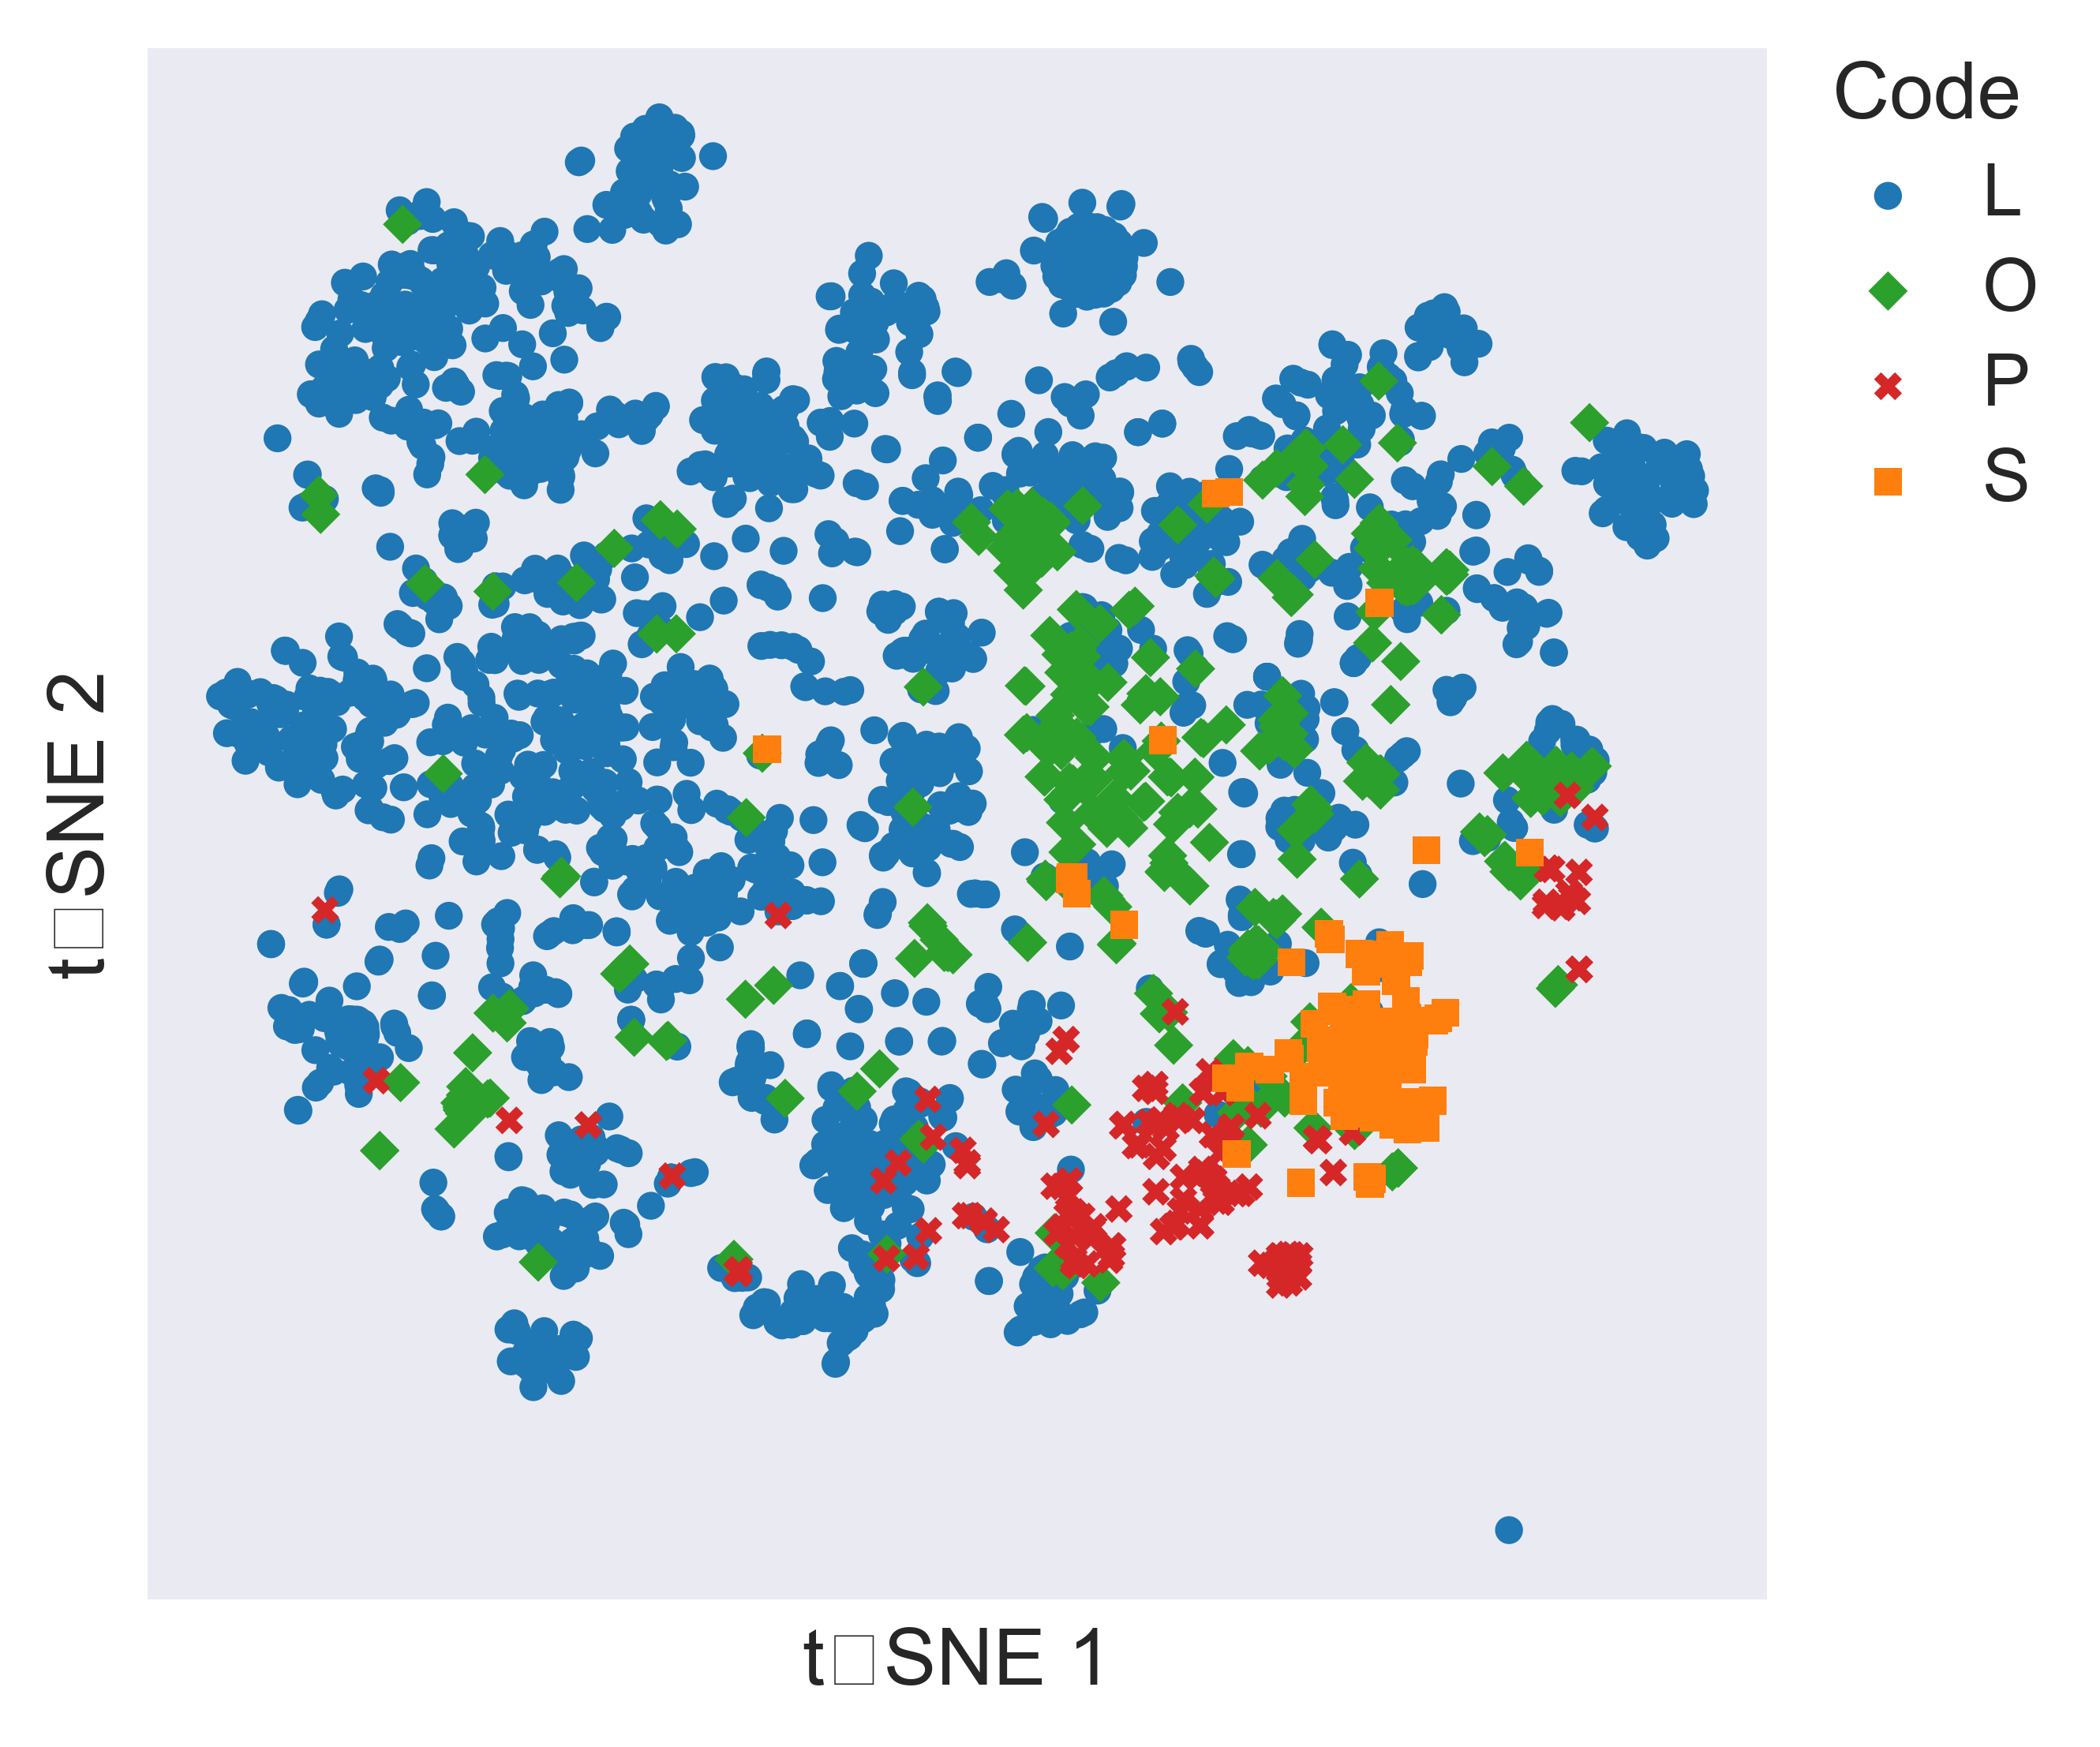

In [6]:
plot_tsne_embeddings(
    embedding_matrix = np.vstack(dataset['embedding']),
    codes = dataset['code'],
    save_as='tsne_no_finetune.png',
)

## Now, let us finetune and see how the landscape of responses has shifted.

Step 1. Create a finetune dataset 

In [7]:
def create_finetune_dataset(centroids):

    # create a list of all the texts
    texts = centroids['text'].tolist()
    combinations = list(product(texts, repeat=2))

    # create a df with the combinations
    combinations_df = pd.DataFrame(combinations, columns=['anchor', 'target'])

    # create a function that checks if the anchor and target have the same code in centroids_df
    def check_code(anchor, target):
        anchor_code = centroids[centroids['text'] == anchor]['code'].values[0]
        target_code = centroids[centroids['text'] == target]['code'].values[0]
        if anchor_code == target_code:
            return float(1)
        else:
            return float(0)
        
    # apply the function to the df
    combinations_df['label'] = combinations_df.apply(lambda x: check_code(x['anchor'], x['target']), axis=1)

    combinations_df.rename(columns={'anchor': 'text1','target': 'text2'}, inplace=True)

    # save the df to a csv
    combinations_df.to_csv('finetune_dataset.csv', index=False)

In [8]:
# Import the centroids 
df = pd.read_excel('centroids.xlsx')
create_finetune_dataset(df)

Step 2. Finetune the initialized model on the finetune dataset.

In [9]:
def finetuner(model, prompt):

    def ensurances():

        # Ensure the model is a SentenceTransformer model
        if not isinstance(model, SentenceTransformer):
            raise ValueError("Invalid model. Use a SentenceTransformer model.")
        
        # Check device configuration
        device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
        print(f"Using device: {device}")

    ensurances()

    # Define the filepaths
    data_filepath = "finetune_dataset.csv"
    output_path = f"models/{model_name}"
    
    # Use the provided output path directly
    model_output_dir = output_path
    print(f"Fine-tuning model, saving to {model_output_dir}.")

    # Ensure output directories exist
    os.makedirs(model_output_dir, exist_ok=True)

    # Load the dataset
    ds = load_dataset("csv", data_files = data_filepath)
    dataset = ds['train']

    training_args = SentenceTransformerTrainingArguments(
    prompts=prompt,
    output_dir=model_output_dir,
    )

    # Define the trainer
    trainer = SentenceTransformerTrainer(
        args=training_args,
        model=model,
        train_dataset=dataset,
        loss= ContrastiveLoss
    )

    # Train the model
    trainer.train()

    # Save the model
    model.save_pretrained(model_output_dir)
    print(f"Model saved to {model_output_dir}!")

In [10]:
# Call the finetuner with full path
finetuner(model, prompt)

torch.cuda.empty_cache()

Using device: mps
Fine-tuning model, saving to models/jinaai/jina-embeddings-v2-base-en.


Generating train split: 8649 examples [00:00, 415239.12 examples/s]


Step,Training Loss
500,0.003200
1000,0.000000
1500,0.000000
2000,0.000000
2500,0.000000
3000,0.000000


Model saved to models/jinaai/jina-embeddings-v2-base-en!


Step 3. Load the new model, and embed the data again.

In [11]:
# initialize model and prompt
# Note: The model_name and prompt can be changed as needed.
ft_model_name = f'models/{model_name}'

ft_model = SentenceTransformer(
    ft_model_name,
    trust_remote_code=True,
    local_files_only=True
)

In [12]:
# embed the dataset
ft_embeddings = ft_model.encode(
    dataset['Response'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

# add embeddings to the dataset
dataset['ft_embedding'] = ft_embeddings.tolist()

dataset.head()

Batches:   0%|          | 0/91 [00:00<?, ?it/s]

Batches: 100%|██████████| 91/91 [00:06<00:00, 13.14it/s]


,Response,code,embedding,ft_embedding
0,Imprecise/faulty measuring tools,L,"[-0.010014945641160011, -0.031923674046993256,...","[-0.03966629132628441, -0.008810184895992279, ..."
1,air fluctuations,L,"[-0.03653107210993767, -0.04496714472770691, 0...","[-7.84511212259531e-05, -0.00782748218625784, ..."
2,Slight differences in experimental setup: tabl...,L,"[-0.04071728140115738, -0.033269673585891724, ...","[0.00857746321707964, -0.010145572945475578, 0..."
3,The material of ramp and ball and the coeffici...,L,"[-0.024769000709056854, -0.057986337691545486,...","[0.0020338373724371195, -0.015696536749601364,..."
4,Materials issues (ball; ramps are identical),L,"[0.02394707500934601, -0.04275062307715416, 0....","[0.0025568169075995684, -0.012979132123291492,..."


## Ft t-SNE plot.

/var/folders/ws/j2ktg5hj42s9mkbwr_c5lbtm0000gs/T/ipykernel_3672/1641009476.py:111: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(pad=0.2)
/var/folders/ws/j2ktg5hj42s9mkbwr_c5lbtm0000gs/T/ipykernel_3672/1641009476.py:114: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.savefig(save_as, bbox_inches="tight")


(<Figure size 2580x2580 with 1 Axes>,
 <Axes: xlabel='t‑SNE\xa01', ylabel='t‑SNE\xa02'>)

/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  func(*args, **kwargs)
/opt/miniconda3/envs/ISF2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


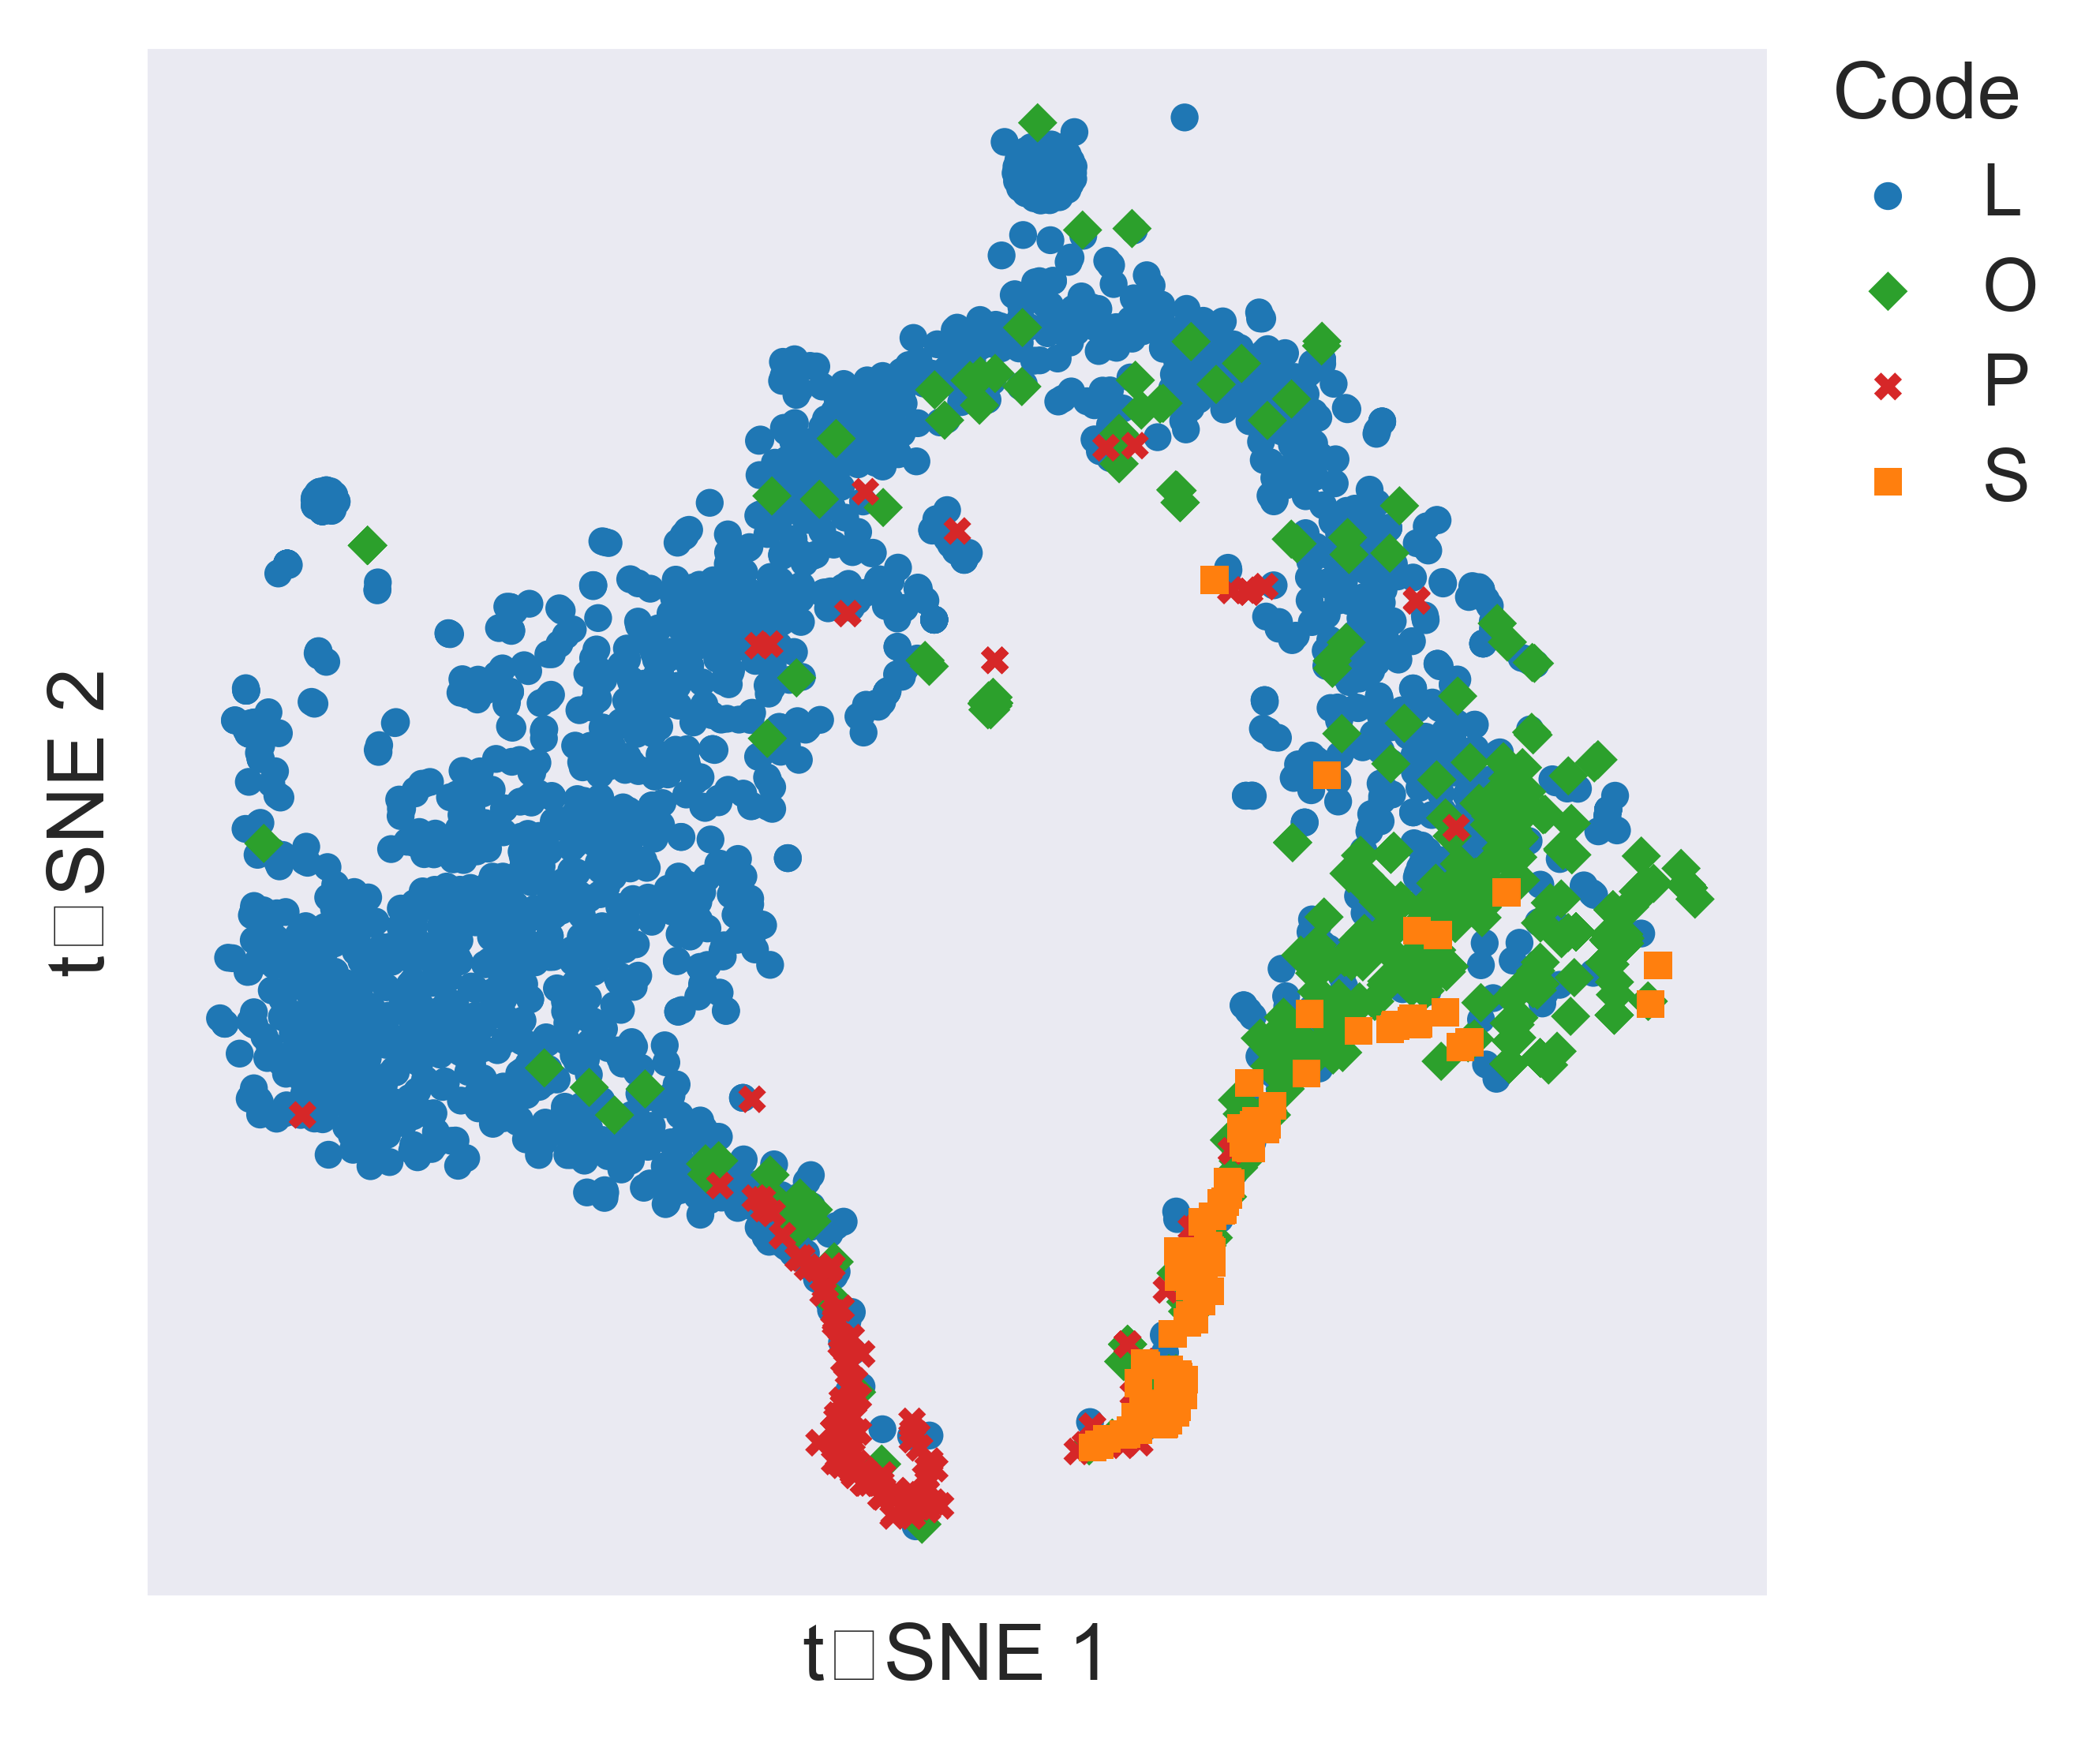

In [13]:
plot_tsne_embeddings(
    embedding_matrix = np.vstack(dataset['ft_embedding']),
    codes = dataset['code'],
    save_as='tsne_yes_finetune.png',
)